In [1]:
# import libraries and mount Drive
import os
import numpy as np
import pandas as pd

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# define dataset paths

PROJECT_DIR = "/content/drive/MyDrive/Brain_Tumor_CNN_Project"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "Epic and CSCR hospital Dataset"
)

TRAIN_DIR = os.path.join(DATASET_DIR, "Train")
TEST_DIR = os.path.join(DATASET_DIR, "Test")

MODELS_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [4]:
# define binary class mapping

CLASS_MAPPING = {
    "glioma": 1,
    "meningioma": 1,
    "pituitary": 1,
    "notumor": 0
}

CLASS_NAMES = {
    0: "Non-Tumourous",
    1: "Tumourous"
}

print("Class mapping:")
for class_name, label in CLASS_MAPPING.items():
    print(f"{class_name:12s} -> {label} ({CLASS_NAMES[label]})")

Class mapping:
glioma       -> 1 (Tumourous)
meningioma   -> 1 (Tumourous)
pituitary    -> 1 (Tumourous)
notumor      -> 0 (Non-Tumourous)


In [5]:
# create image dataframe

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

image_paths = []
labels = []
original_classes = []

for class_name, label in CLASS_MAPPING.items():

    class_path = os.path.join(TRAIN_DIR, class_name)

    for image_file in os.listdir(class_path):

        if image_file.lower().endswith(VALID_EXTENSIONS):

            image_path = os.path.join(class_path, image_file)

            image_paths.append(image_path)
            labels.append(label)
            original_classes.append(class_name)

df = pd.DataFrame({
    "image_path": image_paths,
    "original_class": original_classes,
    "label": labels
})

print("Total training images:", len(df))
df.head()

Total training images: 9650


,image_path,original_class,label
0,/content/drive/MyDrive/Brain_Tumor_CNN_Project...,glioma,1
1,/content/drive/MyDrive/Brain_Tumor_CNN_Project...,glioma,1
2,/content/drive/MyDrive/Brain_Tumor_CNN_Project...,glioma,1
3,/content/drive/MyDrive/Brain_Tumor_CNN_Project...,glioma,1
4,/content/drive/MyDrive/Brain_Tumor_CNN_Project...,glioma,1


In [6]:
# Train/Validation split

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

print("Total images     :", len(df))
print("Training images  :", len(train_df))
print("Validation images:", len(val_df))

Total images     : 9650
Training images  : 7720
Validation images: 1930


In [8]:
# class distribution with names

def show_distribution(dataframe, name):

    print(f"\n{name}")
    print("=" * 40)

    counts = dataframe["label"].value_counts().sort_index()

    for label, count in counts.items():

        class_name = CLASS_NAMES[label]
        percentage = (count / len(dataframe)) * 100

        print(
            f"{class_name:15s}: "
            f"{count:5d} images ({percentage:.2f}%)"
        )


show_distribution(train_df, "TRAINING SET")
show_distribution(val_df, "VALIDATION SET")


TRAINING SET
Non-Tumourous  :  1556 images (20.16%)
Tumourous      :  6164 images (79.84%)

VALIDATION SET
Non-Tumourous  :   389 images (20.16%)
Tumourous      :  1541 images (79.84%)


In [9]:
# check for data leakage

train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])

overlap = train_paths.intersection(val_paths)

print("Images in both training and validation:", len(overlap))

if len(overlap) == 0:
    print("No data leakage detected.")
else:
    print("WARNING: Duplicate image paths found!")

Images in both training and validation: 0
No data leakage detected.


In [10]:
# save tarin / validation splits

train_csv = os.path.join(
    RESULTS_DIR,
    "train_split.csv"
)

val_csv = os.path.join(
    RESULTS_DIR,
    "validation_split.csv"
)

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)

print("Training split saved to:")
print(train_csv)

print("\nValidation split saved to:")
print(val_csv)

Training split saved to:
/content/drive/MyDrive/Brain_Tumor_CNN_Project/results/train_split.csv

Validation split saved to:
/content/drive/MyDrive/Brain_Tumor_CNN_Project/results/validation_split.csv


In [11]:
# define image preprocessing settings

import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Random seed:", SEED)

Image size: (224, 224)
Batch size: 32
Random seed: 42


- 224 × 224 = fixed image dimensions
- 3 = RGB channels
- grayscale images will also be converted to 3 channels
- pixel values will later be normalized to 0–1

In [12]:
# create the image preprocessing function.

def preprocess_image(image_path, label):

    # Read image file
    image = tf.io.read_file(image_path)

    # Decode image and convert to 3-channel RGB (grayscale to RGB conversion)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Ensure TensorFlow knows the image has 3 channels
    image.set_shape([None, None, 3])

    # Resize image
    image = tf.image.resize(image, IMG_SIZE)

    # Normalize pixel values from 0-255 to 0-1
    image = tf.cast(image, tf.float32) / 255.0

    # Convert label to float
    label = tf.cast(label, tf.float32)

    return image, label

Image path → Read image → RGB conversion → Resize 224×224 → Normalize → Batch

In [13]:
# create TensorFlow datasets

# Create training dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values,
     train_df["label"].values)
)

# Apply preprocessing
train_dataset = train_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Shuffle, batch and prefetch
train_dataset = train_dataset.shuffle(
    buffer_size=len(train_df),
    seed=SEED
)

train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)


# Create validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values,
     val_df["label"].values)
)

# Apply preprocessing
val_dataset = val_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Batch and prefetch
val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

print("Training and validation datasets created successfully.")

Training and validation datasets created successfully.


- We shuffle the training dataset because it helps the CNN learn patterns rather than memorize the order in which the images happen to be stored.
- Validation is only used to measure performance, not to update the model's weights. Therefore, there is no learning benefit from shuffling it.

In [14]:
# Take one batch from the training dataset

images, labels = next(iter(train_dataset))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())

print("First 10 labels:", labels[:10].numpy())

Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0
First 10 labels: [0. 1. 0. 1. 1. 1. 1. 0. 1. 1.]


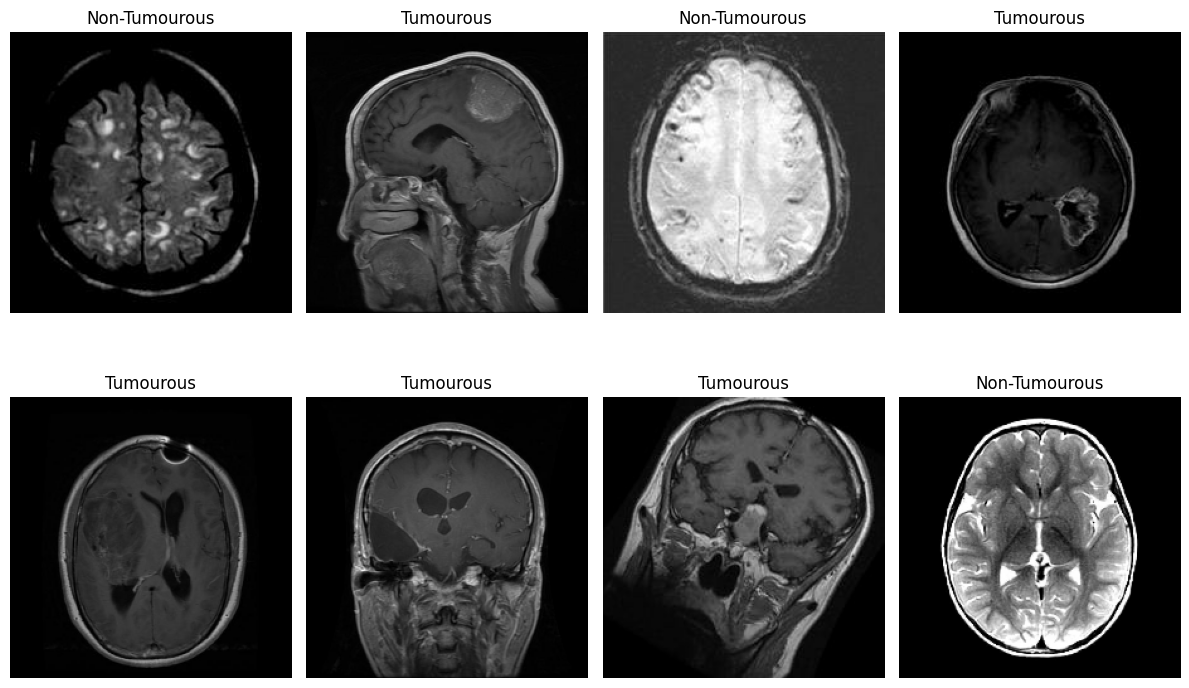

In [18]:
# visually verify preprocessed images

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i].numpy())

    label = int(labels[i].numpy())

    plt.title(CLASS_NAMES[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# calculate class weights

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df["label"])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    int(label): float(weight)
    for label, weight in zip(classes, class_weights_array)
}

print("Class weights:")
for label, weight in class_weights.items():
    print(f"{CLASS_NAMES[label]:15s}: {weight:.4f}")

Class weights:
Non-Tumourous  : 2.4807
Tumourous      : 0.6262


#### **Class Weights**

The binary dataset contains more Tumourous images than Non-Tumourous images.

Class weights are calculated automatically using the training-set distribution. The minority class receives a higher weight, while the majority class receives a lower weight.

During CNN training, these weights help reduce the effect of class imbalance and encourage the model to learn both classes rather than favoring the majority class.

In [20]:
# create test dataframe

test_image_paths = []
test_labels = []
test_original_classes = []

for class_name, label in CLASS_MAPPING.items():

    class_path = os.path.join(TEST_DIR, class_name)

    for image_file in os.listdir(class_path):

        if image_file.lower().endswith(VALID_EXTENSIONS):

            image_path = os.path.join(class_path, image_file)

            test_image_paths.append(image_path)
            test_labels.append(label)
            test_original_classes.append(class_name)

test_df = pd.DataFrame({
    "image_path": test_image_paths,
    "original_class": test_original_classes,
    "label": test_labels
})

print("Total test images:", len(test_df))

Total test images: 2414


In [21]:
# check test-set class distribution

print("TEST SET")
print("=" * 40)

counts = test_df["label"].value_counts().sort_index()

for label, count in counts.items():

    class_name = CLASS_NAMES[label]
    percentage = (count / len(test_df)) * 100

    print(
        f"{class_name:15s}: "
        f"{count:5d} images ({percentage:.2f}%)"
    )

TEST SET
Non-Tumourous  :   487 images (20.17%)
Tumourous      :  1927 images (79.83%)


In [22]:
# create the TensorFlow test dataset

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)

test_dataset = test_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Test dataset created successfully.")

Test dataset created successfully.


In [23]:
# Verify the test images

test_images, test_labels = next(iter(test_dataset))

print("Test image batch shape :", test_images.shape)
print("Test label batch shape :", test_labels.shape)

print("Minimum pixel value:", tf.reduce_min(test_images).numpy())
print("Maximum pixel value:", tf.reduce_max(test_images).numpy())

Test image batch shape : (32, 224, 224, 3)
Test label batch shape : (32,)
Minimum pixel value: 0.0
Maximum pixel value: 0.99579805
